In [1]:
import torch 
from torch.utils.data import DataLoader,Dataset,TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('riceClassification.csv')
df.head()

,id,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,1,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,4,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,5,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


In [3]:
df.columns

Index(['id', 'Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')

In [4]:
df.shape

(18185, 12)

In [5]:
df.isna().sum()

id                 0
Area               0
MajorAxisLength    0
MinorAxisLength    0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Perimeter          0
Roundness          0
AspectRation       0
Class              0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.dtypes

id                   int64
Area                 int64
MajorAxisLength    float64
MinorAxisLength    float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Perimeter          float64
Roundness          float64
AspectRation       float64
Class                int64
dtype: object

In [8]:
df.drop('id',inplace=True,axis=1)
df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,EquivDiameter,Extent,Perimeter,Roundness,AspectRation,Class
0,4537,92.229316,64.012769,0.719916,4677,76.004525,0.657536,273.085,0.764510,1.440796,1
1,2872,74.691881,51.400454,0.725553,3015,60.471018,0.713009,208.317,0.831658,1.453137,1
2,3048,76.293164,52.043491,0.731211,3132,62.296341,0.759153,210.012,0.868434,1.465950,1
3,3073,77.033628,51.928487,0.738639,3157,62.551300,0.783529,210.657,0.870203,1.483456,1
4,3693,85.124785,56.374021,0.749282,3802,68.571668,0.769375,230.332,0.874743,1.510000,1


<Axes: title={'center': 'Data Distribution for the various classes'}, xlabel='Class'>

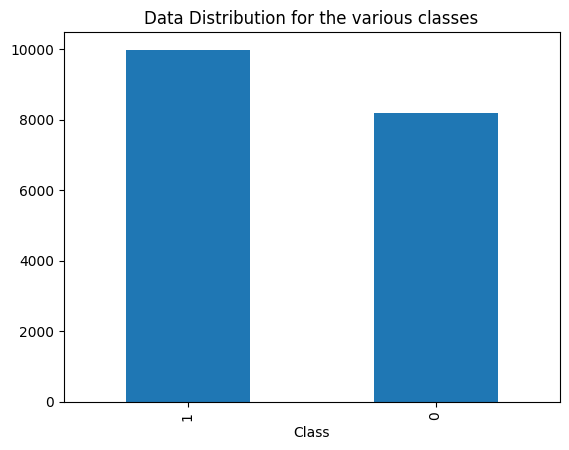

In [9]:
df['Class'].value_counts().plot(kind='bar',title='Data Distribution for the various classes')

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Area,18185.0,7036.492989,1467.197150,2522.000000,5962.000000,6660.000000,8423.000000,10210.000000
MajorAxisLength,18185.0,151.680754,12.376402,74.133114,145.675910,153.883750,160.056214,183.211434
MinorAxisLength,18185.0,59.807851,10.061653,34.409894,51.393151,55.724288,70.156593,82.550762
Eccentricity,18185.0,0.915406,0.030575,0.676647,0.891617,0.923259,0.941372,0.966774
ConvexArea,18185.0,7225.817872,1502.006571,2579.000000,6125.000000,6843.000000,8645.000000,11008.000000
EquivDiameter,18185.0,94.132952,9.906250,56.666658,87.126656,92.085696,103.559146,114.016559
Extent,18185.0,0.616653,0.104389,0.383239,0.538530,0.601194,0.695664,0.886573
Perimeter,18185.0,351.606949,29.500620,197.015000,333.990000,353.088000,373.003000,508.511000
Roundness,18185.0,0.707998,0.067310,0.174590,0.650962,0.701941,0.769280,0.904748
AspectRation,18185.0,2.599081,0.434836,1.358128,2.208527,2.602966,2.964101,3.911845


In [11]:
transformer = StandardScaler()

In [12]:
device = 'cuda' if torch.cuda.is_available else 'cpu'

In [13]:
X = transformer.fit_transform(np.array(df.iloc[0:,0:-1]))
X = torch.tensor(X,dtype=torch.float32).to(device)
X[0]

tensor([-1.7036, -4.8037,  0.4179, -6.3939, -1.6970, -1.8300,  0.3917, -2.6618,
         0.8396, -2.6638], device='cuda:0')

In [14]:
Y = np.array(df['Class'])
Y = torch.tensor(Y,dtype=torch.float32).to(device)
Y

tensor([1., 1., 1.,  ..., 0., 0., 0.], device='cuda:0')

In [15]:
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,test_size=0.3,random_state=42)
xtest,xval,ytest,yval = train_test_split(xtest,ytest,test_size=0.5,random_state=42)

print(f'Training data percentage is: {round((xtrain.shape[0] / X.shape[0]) * 100)}')
print(f'Testing data percentage is: {round((xtest.shape[0] / X.shape[0]) * 100)}')
print(f'Validation data percentage is: {round((xval.shape[0] / X.shape[0]) * 100)}')

Training data percentage is: 70
Testing data percentage is: 15
Validation data percentage is: 15


In [16]:
train_loader = DataLoader(TensorDataset(xtrain,ytrain),batch_size=8,shuffle=True)
test_loader = DataLoader(TensorDataset(xtest,ytest),batch_size=8,shuffle=True)
val_loader = DataLoader(TensorDataset(xval,yval),batch_size=8,shuffle=True)

In [17]:
for inputs,label in train_loader:
    print(inputs.shape[0])
    break

8


In [18]:
import torch.nn as nn 
from torch.optim import Adam
from torchinfo import summary

In [19]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()

        self.input_layer = nn.Linear(X.shape[1],20)
        self.layer_1 = nn.Linear(20,12)
        self.layer_2 = nn.Linear(12,6)
        self.layer_3 = nn.Linear(6,1)
        self.in_activation = nn.ReLU()
        self.out_activation = nn.Sigmoid()

    
    def forward(self,x):
        x = self.in_activation(self.input_layer(x))
        x = self.in_activation(self.layer_1(x))
        x = self.in_activation(self.layer_2(x))
        x = self.out_activation(self.layer_3(x))
        return x 

In [20]:
model = MyModel().to(device)

In [21]:
summary(model=model,input_size=(X.shape[1],))

Layer (type:depth-idx)                   Output Shape              Param #
MyModel                                  [1]                       --
├─Linear: 1-1                            [20]                      220
├─ReLU: 1-2                              [20]                      --
├─Linear: 1-3                            [12]                      252
├─ReLU: 1-4                              [12]                      --
├─Linear: 1-5                            [6]                       78
├─ReLU: 1-6                              [6]                       --
├─Linear: 1-7                            [1]                       7
├─Sigmoid: 1-8                           [1]                       --
Total params: 557
Trainable params: 557
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.01
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [22]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(),lr=0.001)
epochs = 20

In [23]:
len(train_loader)

1592

In [24]:
len(xtrain)

12729

In [ ]:
for epoch in range(epochs):
    model.train()
    total_correct = 0
    total_loss = 0

    for data in train_loader:
        inputs,labels = data 

        prediction = model(inputs).squeeze(1)

        correct = (prediction.round() == labels).sum().item()
        total_correct += correct

        batch_loss = criterion(prediction,labels)
        loss = batch_loss.item()
        total_loss += loss

        batch_acc = correct / inputs.shape[0]
        

        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()


    model.eval()
    total_val_correct, total_val_loss = 0,0
    with torch.no_grad():
        for data in val_loader:
            inputs,labels = data

            prediction = model(inputs).squeeze(1)
            val_correct = (prediction.round() == labels).sum().item()
            total_val_correct += val_correct
            batch_loss = criterion(prediction,labels)
            val_loss = batch_loss.item()
            total_val_loss += val_loss

    train_accuracy = total_correct / len(xtrain)
    train_loss = total_loss / len(train_loader)
    val_accuracy = total_val_correct / len(xval)
    val_loss = total_val_loss / len(val_loader)
   
 
    print(f"Epoch: {epoch+1} | "
          f"Train Acc: {train_accuracy:.4f} | Train Loss: {train_loss:.4f} | "
          f"Val Acc: {val_accuracy:.4f} | Val Loss: {val_loss:.4f} | "
          f'Train Batch Acc: {batch_acc:.4f}')

Epoch: 1 | Train Acc: 0.9767 | Train Loss: 0.2502 | Val Acc: 0.9875 | Val Loss: 0.1442 | Batch Acc: 1.0000
Epoch: 2 | Train Acc: 0.9877 | Train Loss: 0.1103 | Val Acc: 0.9864 | Val Loss: 0.0860 | Batch Acc: 1.0000
Epoch: 3 | Train Acc: 0.9885 | Train Loss: 0.0709 | Val Acc: 0.9864 | Val Loss: 0.0598 | Batch Acc: 1.0000
Epoch: 4 | Train Acc: 0.9892 | Train Loss: 0.0545 | Val Acc: 0.9835 | Val Loss: 0.0561 | Batch Acc: 1.0000
Epoch: 5 | Train Acc: 0.9891 | Train Loss: 0.0464 | Val Acc: 0.9868 | Val Loss: 0.0462 | Batch Acc: 1.0000
Epoch: 6 | Train Acc: 0.9891 | Train Loss: 0.0424 | Val Acc: 0.9864 | Val Loss: 0.0444 | Batch Acc: 1.0000
Epoch: 7 | Train Acc: 0.9894 | Train Loss: 0.0401 | Val Acc: 0.9875 | Val Loss: 0.0406 | Batch Acc: 1.0000
Epoch: 8 | Train Acc: 0.9893 | Train Loss: 0.0381 | Val Acc: 0.9875 | Val Loss: 0.0388 | Batch Acc: 1.0000
Epoch: 9 | Train Acc: 0.9896 | Train Loss: 0.0366 | Val Acc: 0.9883 | Val Loss: 0.0403 | Batch Acc: 1.0000
Epoch: 10 | Train Acc: 0.9894 | Train